# Ugail–Howard Consciousness Dynamics — State Simulators
## Physiologically motivated EEG-like generators for nine canonical conscious states

**Authors:** Hassan Ugail & Newton Howard

Cite: H. Ugail and N. Howard, “Quantifying the dynamics of consciousness using hierarchical integration, organised complexity and metastability,” arXiv preprint arXiv:2512.10972, Dec. 2025.


---

This notebook is the **standalone simulator release** for the Ugail–Howard
framework. It provides:

1. the full set of **nine state simulators** — Wake, Task-engaged, Dreaming,
   Sleep (NREM-like), Minimally Conscious, Anaesthesia, Non-conscious (UWS),
   Seizure, Psychedelic — plus a calibrated REM-sleep generator;
2. the same core metric pipeline ($H_{\mathrm{eff}}$, $D$, $M$, $\Psi$) so
   you can exercise the index on any simulated state immediately;
3. a demonstration cell that draws one realisation per state, plots example
   traces, and reports the Table-1-style metrics.

It has **no external dataset dependencies**; top-to-bottom execution in any
Python 3.9+ environment produces the full set of state examples.

### State parametrisation

Each state is a dictionary of dynamical ingredients (band weights, PAC
strength, Kuramoto coupling, local vs global synchrony). Three states —
**Seizure**, **Non-conscious**, and **REM sleep** — are generated in the
frequency domain or via a direct template to match published clinical
signatures (Casali et al., 2013; Sitt et al., 2014; Pereda et al., 2001).
The result is a signal ensemble whose ordering in $\Psi$ follows the
expected consciousness hierarchy:

> Psychedelic  ≳  Wake  ≳  Task-engaged  >  Dreaming  >  Sleep (NREM)  >
> Minimally Conscious  >  Anaesthesia  >  Non-conscious  >  Seizure


### Circularity caveat
The generators parameterise the same dynamical motifs (scale-free structure,
PAC, Kuramoto coupling) that $\Psi$ measures. State separation in this
notebook therefore demonstrates that the measurement pipeline recovers its
input — it does **not** constitute independent evidence that $\Psi$ tracks
phenomenal consciousness. That test is performed on real EEG in the
empirical-validation companion notebook.


In [1]:
# Install dependencies (run once per environment; safe to skip if already installed)
# Uncomment the line below if running in a fresh Colab / notebook kernel.
# !pip install -q numpy scipy matplotlib pandas networkx
print("Dependency cell — uncomment pip line above if needed.")


Dependency cell — uncomment pip line above if needed.


In [2]:
# ── Imports & global configuration ─────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.signal import butter, filtfilt, hilbert

np.random.seed(42)

CFG = {
    "fs":      250,
    "H_opt":   0.35,
    "sigma_H": 0.12,
    "w_H":     0.40,
    "w_D":     0.35,
    "w_M":     0.25,
    "lam":     1.0,
    "GAMMA_HIGH_SYN":  80,
    "GAMMA_HIGH_REAL": 45,
}

plt.rcParams.update({
    "figure.dpi":      120,
    "font.size":       11,
    "axes.titlesize":  12,
    "axes.labelsize":  11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "legend.frameon":    False,
})

print("Imports loaded. NumPy", np.__version__)
print(f"  Psi = {CFG['w_H']:.2f}*H_eff + {CFG['w_D']:.2f}*D + {CFG['w_M']:.2f}*M")


Imports loaded. NumPy 2.0.2
  Psi = 0.40*H_eff + 0.35*D + 0.25*M


In [3]:
# ── Basic signal utilities (identical to core notebook) ────────────────────

def bandpass_filter(data, fs, low, high, order=4):
    """Zero-phase Butterworth bandpass filter along the last axis."""
    nyq = fs / 2.0
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, data, axis=-1)


def generate_pink_noise(n_channels, n_samples):
    """Approximate 1/f pink noise by cumulative-summed white noise."""
    white = np.random.randn(n_channels, n_samples)
    pink = np.cumsum(white, axis=-1)
    pink -= pink.mean(axis=-1, keepdims=True)
    pink /= pink.std(axis=-1, keepdims=True) + 1e-9
    return pink


print("Signal utilities loaded.")


Signal utilities loaded.


In [4]:
# ── Core metrics: DFA, Lempel-Ziv, Tort MI ─────────────────────────────────
# Returns DFA scaling exponent alpha (not Hurst). For cumulative-sum signals:
#   alpha in (0.5, 1) = persistent, alpha > 1 = non-stationary fBm-like.

def dfa_hurst(x, min_win=16, max_win=None, n_win=10):
    """DFA scaling exponent alpha of a 1-D signal."""
    x = np.asarray(x)
    N = x.size
    if max_win is None:
        max_win = N // 4
    y = np.cumsum(x - x.mean())
    s_vals = np.unique(
        np.logspace(np.log10(min_win), np.log10(max_win), n_win, dtype=int)
    )
    F = []
    for s in s_vals:
        if s < 4:
            continue
        n_seg = N // s
        if n_seg < 2:
            continue
        rms = []
        for i in range(n_seg):
            seg = y[i * s : (i + 1) * s]
            t = np.arange(s)
            p = np.polyfit(t, seg, 1)
            rms.append(np.sqrt(np.mean((seg - np.polyval(p, t)) ** 2)))
        if rms:
            F.append(np.mean(rms))
    F = np.array(F)
    if len(F) < 2:
        return 0.5
    s_use = s_vals[: len(F)]
    return float(np.polyfit(np.log(s_use), np.log(F), 1)[0])


def lempel_ziv_complexity(binary_seq):
    """Normalised LZ76 complexity of a binary sequence."""
    s = "".join(str(int(b)) for b in binary_seq)
    i, c, l = 0, 1, 1
    n = len(s)
    while True:
        if i + l > n:
            c += 1
            break
        sub = s[i : i + l]
        if sub in s[:i]:
            l += 1
        else:
            i += l
            c += 1
            l = 1
        if i + l > n:
            break
    return c / n


def mutual_information_phase_amp(phase, amp, n_bins=36):
    """Tort (2010) Modulation Index with amplitude guard (Aru et al. 2015).

    Guards against numerical artefacts from near-zero amplitude signals:
    when mean |amp| < 1e-3 on a z-scored signal, the KL divergence is
    dominated by rounding noise rather than genuine PAC. We return 0.
    """
    phase = np.asarray(phase)
    amp   = np.asarray(amp)
    if float(amp.mean()) < 1e-3:
        return 0.0
    bins = np.linspace(-np.pi, np.pi, n_bins + 1)
    amp_profile = np.zeros(n_bins)
    for i in range(n_bins):
        mask = (phase >= bins[i]) & (phase < bins[i + 1])
        amp_profile[i] = amp[mask].mean() if mask.sum() > 0 else 0.0
    total = amp_profile.sum()
    if total < 1e-12:
        return 0.0
    p = amp_profile / total
    q = np.ones(n_bins) / n_bins
    return float(np.sum(p * np.log(p / q + 1e-12)))


print("Core metrics loaded: DFA alpha, Lempel-Ziv, Tort MI (with amplitude guard).")


Core metrics loaded: DFA alpha, Lempel-Ziv, Tort MI (with amplitude guard).


In [5]:
# ── compute_metrics pipeline (H_eff, D, M, Psi) ────────────────────────────

def compute_metrics(X, fs=250, Hopt=0.35, sigma_H=0.12, lam=1.0, **kwargs):
    """Compute H_raw, H_eff, D, M, Psi on a multichannel signal.

    H_eff formula: range-normalised triangular penalty.
        H_eff = max(0, 1 − |alpha − H_opt| / alpha_range)
    where alpha_range defaults to 3*sigma_H if not passed as a kwarg.
    """
    C, T = X.shape
    H_vals = np.array([dfa_hurst(X[ch]) for ch in range(C)])
    H_raw  = float(H_vals.mean())
    _alpha_range = kwargs.get("alpha_range", 3.0 * sigma_H)
    Heff = float(max(0.0, 1.0 - abs(H_raw - Hopt) / _alpha_range))

    theta = bandpass_filter(X, fs, 4, 8)
    gamma_high = kwargs.get("gamma_high", 80)
    gamma = bandpass_filter(X, fs, 30, gamma_high)
    theta_phase = np.angle(hilbert(theta, axis=-1))
    gamma_amp   = np.abs(hilbert(gamma, axis=-1))
    I_phiA = float(np.mean([
        mutual_information_phase_amp(theta_phase[ch], gamma_amp[ch])
        for ch in range(C)]))

    broadband = bandpass_filter(X, fs, 1, 40)
    amp_bb = np.abs(hilbert(broadband, axis=-1))
    LZ_vals = []
    for ch in range(C):
        env = amp_bb[ch]
        binary = (env > np.median(env)).astype(int)
        LZ_vals.append(lempel_ziv_complexity(binary))
    LZ = float(np.mean(LZ_vals))
    D = I_phiA * (1.0 + lam * LZ)

    alpha_band = bandpass_filter(X, fs, 8, 13)
    alpha_phase = np.angle(hilbert(alpha_band, axis=-1))
    R_t = np.abs(np.mean(np.exp(1j * alpha_phase), axis=0))
    M = float(np.std(R_t))

    Psi = 0.40 * Heff + 0.35 * D + 0.25 * M
    return {"H_raw": H_raw, "Heff": Heff, "D": D, "M": M, "Psi": Psi}


def compute_all_metrics(X, fs, gamma_high=80):
    """Raw-component wrapper for ensemble analyses."""
    m = compute_metrics(X, fs=fs, Hopt=0.35, sigma_H=0.12,
                        lam=1.0, gamma_high=gamma_high)
    return {"H": m["H_raw"], "D": m["D"], "M": m["M"]}


print("compute_metrics and compute_all_metrics ready.")


compute_metrics and compute_all_metrics ready.


In [6]:
# ── EEG-like state simulator: 9 canonical states + REM sleep ───────────────
# 'Conscious' renamed to 'Task-engaged' for consistency with the manuscript.

def generate_consciousness_state_signal(state="wake", n_channels=20,
                                         duration=12, fs=250):
    """EEG-like multichannel signal for 9 conscious states + REM sleep.

    Supported states:
        wake, task_engaged, sleep, anesthesia, psychedelic,
        seizure, minimally_conscious, non_conscious,
        dreaming (alias of psychedelic), rem_sleep

    Returns
    -------
    signal : array, shape (n_channels, duration*fs), z-scored per channel.

    Notes
    -----
    Seizure and non_conscious signals are constructed in the frequency
    domain and tiled across channels — producing D ~ 0 and M ~ 0 by
    construction, matching the clinical signatures of GTC seizures and
    chronic UWS respectively.
    """
    n_samples = int(duration * fs)

    params = {
        "wake": {
            "bands": {"delta":0.3,"theta":0.4,"alpha":0.8,"beta":0.6,"gamma":0.5},
            "coupling":0.6,"local_sync":0.3,"global_sync":0.5,"pac_strength":0.4,
        },
        # Task-engaged — higher PAC, lower global sync than resting wake
        "task_engaged": {
            "bands": {"delta":0.2,"theta":0.5,"alpha":0.7,"beta":0.7,"gamma":0.6},
            "coupling":0.55,"local_sync":0.50,"global_sync":0.35,"pac_strength":0.55,
        },
        "sleep": {
            "bands": {"delta":0.95,"theta":0.7,"alpha":0.2,"beta":0.1,"gamma":0.05},
            "coupling":0.4,"local_sync":0.7,"global_sync":0.3,"pac_strength":0.05,
        },
        "anesthesia": {
            "bands": {"delta":0.9,"theta":0.5,"alpha":0.5,"beta":0.05,"gamma":0.02},
            "coupling":0.10,"local_sync":0.82,"global_sync":0.08,"pac_strength":0.005,
        },
        "psychedelic": {
            "bands": {"delta":0.2,"theta":0.4,"alpha":0.6,"beta":0.8,"gamma":1.0},
            "coupling":0.7,"local_sync":0.2,"global_sync":0.4,"pac_strength":0.7,
        },
        # Seizure — generalised tonic-clonic; delta-dominated 1/f^2 tiled across ch
        "seizure": {
            "bands": {"delta":0.0,"theta":0.0,"alpha":0.0,"beta":0.0,"gamma":0.0},
            "coupling":0.0,"local_sync":0.0,"global_sync":1.0,"pac_strength":0.0,
        },
        # Minimally Conscious — all three components favour MCS > Anaesthesia
        "minimally_conscious": {
            "bands": {"delta":0.55,"theta":0.35,"alpha":0.25,"beta":0.05,"gamma":0.0},
            "coupling":0.32,"local_sync":0.45,"global_sync":0.12,"pac_strength":0.060,
        },
        # Non-conscious (UWS) — super-Brownian 1/f^2 over 0.3–5.5 Hz
        "non_conscious": {
            "bands": {"delta":0.0,"theta":0.0,"alpha":0.0,"beta":0.0,"gamma":0.0},
            "coupling":0.0,"local_sync":0.0,"global_sync":0.0,"pac_strength":0.0,
        },
    }

    # REM sleep handled separately (see _sim_rem in the next cell)
    if state == "rem_sleep":
        raise ValueError("Use _sim_rem() for REM sleep — not handled here.")
    if state == "dreaming":
        state = "psychedelic"
    if state not in params:
        raise ValueError(f"Unknown state '{state}', choose from {list(params.keys())}")

    p = params[state]
    band_edges = {"delta":(1,4),"theta":(4,8),"alpha":(8,13),
                  "beta":(13,30),"gamma":(30,80)}

    base = generate_pink_noise(n_channels, n_samples)
    signal = np.zeros_like(base)

    # 1) Band-limited global + local mixture ─────────────────────────────
    for band_name, weight in p["bands"].items():
        if weight <= 0:
            continue
        low, high = band_edges[band_name]
        global_src = bandpass_filter(
            np.random.randn(1, n_samples), fs, low, high)[0]
        global_src -= global_src.mean()
        global_src /= global_src.std() + 1e-9

        for ch in range(n_channels):
            local = bandpass_filter(base[ch:ch+1, :], fs, low, high)[0]
            local -= local.mean()
            local /= local.std() + 1e-9
            mix = (1.0 - p["global_sync"]) * local + p["global_sync"] * global_src
            signal[ch] += weight * mix

    # 2) Theta–gamma PAC injection ───────────────────────────────────────
    if p["pac_strength"] > 0:
        theta_low, theta_high = band_edges["theta"]
        gamma_low, gamma_high = band_edges["gamma"]
        theta = bandpass_filter(signal, fs, theta_low, theta_high)
        theta_phase = np.angle(hilbert(theta, axis=-1))
        gamma_noise = np.random.randn(n_channels, n_samples) * 0.5
        gamma_filtered = bandpass_filter(gamma_noise, fs, gamma_low, gamma_high)
        pac_mod = (1.0 + p["pac_strength"] * np.sin(theta_phase)) / 2.0
        signal += pac_mod * gamma_filtered * 3.0

    # 3a) Seizure — generative 1/f^2 in 0.5–4 Hz, tiled (D=0, M=0) ──────
    if state == "seizure":
        _n = n_samples
        _f = np.fft.rfftfreq(_n, 1.0 / fs)
        _f[0] = 1e-9
        _brown = np.where((_f >= 0.5) & (_f <= 4.0), 1.0 / _f ** 2, 0.0)
        _white = np.where(_f >= 4.0, 0.03, 0.0)
        _spec  = (_brown + _white) * (
            np.random.randn(len(_f)) + 1j * np.random.randn(len(_f)))
        _ictal = np.fft.irfft(_spec, n=_n)
        _ictal -= _ictal.mean(); _ictal /= _ictal.std() + 1e-9
        signal = np.tile(_ictal, (n_channels, 1))

    # 3b) Non-conscious (UWS) — super-Brownian 1/f^2 in 0.3–5.5 Hz ──────
    if state == "non_conscious":
        _n = n_samples
        _f = np.fft.rfftfreq(_n, 1.0 / fs)
        _f[0] = 1e-9
        _brown = np.where((_f >= 0.3) & (_f <= 5.5), 1.0 / _f ** 2, 0.0)
        _white = np.where(_f >= 5.5, 0.02, 0.0)
        _spec  = (_brown + _white) * (
            np.random.randn(len(_f)) + 1j * np.random.randn(len(_f)))
        _uws = np.fft.irfft(_spec, n=_n)
        _uws -= _uws.mean(); _uws /= _uws.std() + 1e-9
        signal = np.tile(_uws, (n_channels, 1))

    # 4) Network-based phase coupling (skipped for tiled signals) ───────
    if n_channels > 1 and p["coupling"] > 0 and state not in ("seizure", "non_conscious"):
        if p["local_sync"] > 0.5:
            G = nx.watts_strogatz_graph(n_channels, k=min(4, n_channels-1), p=0.05)
        else:
            G = nx.watts_strogatz_graph(n_channels, k=min(4, n_channels-1), p=0.3)
        A = nx.to_numpy_array(G)
        A = A / (A.sum(axis=1, keepdims=True) + 1e-9)
        analytic = hilbert(signal, axis=-1)
        amp   = np.abs(analytic)
        phase = np.angle(analytic)
        for t_idx in range(1, n_samples):
            phase_diff = (phase[:, t_idx-1][:, None] - phase[:, t_idx-1][None, :])
            coupling_term = (A * np.sin(phase_diff)).sum(axis=1)
            phase[:, t_idx] += p["coupling"] * 0.02 * coupling_term
        signal = amp * np.cos(phase)

    # 5) Per-channel z-score ─────────────────────────────────────────────
    signal -= signal.mean(axis=-1, keepdims=True)
    signal /= signal.std(axis=-1, keepdims=True) + 1e-9
    return signal


print("generate_consciousness_state_signal() ready for 8 of 9 states (REM next).")


generate_consciousness_state_signal() ready for 8 of 9 states (REM next).


In [7]:
# ── REM sleep simulator + convenience wrappers ─────────────────────────────

def _sim_rem(n_channels=16, T=3000, fs=250):
    """Direct REM-sleep simulator, calibrated for the W > REM > N2 ordering.

    alpha_dfa ~ 0.90 (between Wake ~0.69 and NREM ~0.02 in the
    range-normalised triangular scoring). Biologically: theta-prominent,
    reduced alpha, moderate delta, lower PAC than dreaming, moderate
    Kuramoto coupling.
    """
    bands = {"delta":0.55,"theta":0.60,"alpha":0.40,"beta":0.35,"gamma":0.28}
    band_freqs = {"delta":(1,4),"theta":(4,8),"alpha":(8,13),
                  "beta":(13,30),"gamma":(30,80)}
    X = generate_pink_noise(n_channels, T) * 0.2
    t = np.arange(T) / fs
    for band, (lo, hi) in band_freqs.items():
        fc = (lo + hi) / 2
        w  = bands[band]
        gosc = np.sin(2*np.pi*fc*t + np.random.uniform(0, 2*np.pi))
        for ch in range(n_channels):
            X[ch] += w * (0.6*gosc
                          + 0.4*np.sin(2*np.pi*fc*t + np.random.uniform(0, 2*np.pi)))
    # Moderate PAC (less than dreaming)
    pac = 0.20
    theta = bandpass_filter(X, fs, 4, 8)
    th_ph = np.angle(hilbert(theta, axis=-1))
    for ch in range(n_channels):
        gn = np.random.randn(T) * 0.3
        gf = bandpass_filter(gn[np.newaxis, :], fs, 30, 80)[0]
        X[ch] += (1 + pac*np.sin(th_ph[ch])) / 2 * gf * 2.0
    # Moderate slow drift
    X += 0.30 * np.sin(2*np.pi*0.5*t)[np.newaxis, :]
    X -= X.mean(axis=-1, keepdims=True)
    X /= (X.std(axis=-1, keepdims=True) + 1e-9)
    return X


# ── Convenience wrappers (uniform signature) ──────────────────────────────
def simulate_state_fast(n_channels=16, T=3000, fs=250, state="wake"):
    if state == "rem_sleep":
        return _sim_rem(n_channels=n_channels, T=T, fs=fs)
    return generate_consciousness_state_signal(
        state=state, n_channels=n_channels, duration=T/fs, fs=fs)

def simulate_task_engaged_state(n_channels=16, T=3000, fs=250):
    return simulate_state_fast(n_channels, T, fs, state="task_engaged")

def simulate_non_conscious_state(n_channels=16, T=3000, fs=250):
    return simulate_state_fast(n_channels, T, fs, state="non_conscious")

def simulate_minimally_conscious_state(n_channels=16, T=3000, fs=250):
    return simulate_state_fast(n_channels, T, fs, state="minimally_conscious")

def simulate_dreaming_state(n_channels=16, T=3000, fs=250):
    # Dreaming is modelled with the psychedelic parameter set
    return simulate_state_fast(n_channels, T, fs, state="psychedelic")

def simulate_rem_sleep_state(n_channels=16, T=3000, fs=250):
    return _sim_rem(n_channels=n_channels, T=T, fs=fs)


# Display-label map (manuscript conventions)
STATE_DISPLAY = {
    "wake":                "Wake",
    "task_engaged":        "Task-engaged",
    "dreaming":            "Dreaming",
    "sleep":               "Sleep (NREM-like)",
    "minimally_conscious": "Minimally Conscious",
    "anesthesia":          "Anaesthesia",
    "non_conscious":       "Non-conscious",
    "seizure":             "Seizure",
    "psychedelic":         "Psychedelic",
    "rem_sleep":           "REM sleep",
}

print("Simulator wrappers ready:", list(STATE_DISPLAY.keys()))


Simulator wrappers ready: ['wake', 'task_engaged', 'dreaming', 'sleep', 'minimally_conscious', 'anesthesia', 'non_conscious', 'seizure', 'psychedelic', 'rem_sleep']


In [8]:
# ── Population helpers (normalisation) ─────────────────────────────────────
# These mirror the core notebook so the simulator output can be scored
# directly in this notebook without needing the experiments pipeline.

def heff_from_population(H_values, H_opt=0.35):
    """Range-normalised triangular H_eff across a population of alpha values."""
    H_values = np.asarray(H_values, dtype=float)
    alpha_range = float(H_values.max() - H_values.min())
    if alpha_range < 1e-9:
        return np.zeros_like(H_values)
    return np.maximum(0.0, 1.0 - np.abs(H_values - H_opt) / alpha_range)


def minmax_normalise(values):
    """Min-max scale to [0, 1]."""
    v = np.asarray(values, dtype=float)
    v_min, v_max = v.min(), v.max()
    return (v - v_min) / (v_max - v_min + 1e-12) if v_max > v_min else np.zeros_like(v)


def psi_from_components(H_eff, D, M, w_H=0.40, w_D=0.35, w_M=0.25):
    """Composite Psi from already-normalised components."""
    return w_H * np.asarray(H_eff) + w_D * np.asarray(D) + w_M * np.asarray(M)


print("Population-level helpers ready.")


Population-level helpers ready.


In [9]:
# ── Demonstration: Monte Carlo across 9 states (matches paper Figs 2 & 5) ──
# We run N_RUNS_PER_STATE = 30 realisations per state, compute (H, D, M)
# on each, then derive H_eff (range-normalised triangular) and Psi across
# the full ensemble. This reproduces the Monte Carlo used to generate
# Figure 2 (Psi bars + SD) and Figure 5 (component bars) in the paper.
#
# Runtime: ~1-2 minutes for 9 states x 30 runs at T=3000 on a modern laptop.
# Set N_RUNS_PER_STATE = 10 for a fast sanity run (noisier error bars).

N_RUNS_PER_STATE = 30

mc_states = ["wake", "task_engaged", "psychedelic", "dreaming",
             "sleep", "minimally_conscious", "anesthesia",
             "non_conscious", "seizure"]

print(f"Monte Carlo: {N_RUNS_PER_STATE} runs per state x {len(mc_states)} states = "
      f"{N_RUNS_PER_STATE * len(mc_states)} total realisations")
print()

mc_rows = []
sim_cache = {}   # keep one realisation per state for example time traces
for st in mc_states:
    print(f"  {st:22s}", end="", flush=True)
    for run_idx in range(N_RUNS_PER_STATE):
        X = simulate_state_fast(n_channels=16, T=3000, fs=CFG["fs"], state=st)
        if run_idx == 0:
            sim_cache[st] = X
        m = compute_all_metrics(X, CFG["fs"], gamma_high=CFG["GAMMA_HIGH_SYN"])
        m["state_raw"] = st
        m["state"]     = STATE_DISPLAY[st]
        mc_rows.append(m)
    print("  done")

mc_df = pd.DataFrame(mc_rows)

# Range-normalised H_eff across the full MC ensemble
_alpha_range_mc = float(mc_df["H"].max() - mc_df["H"].min())
print(f"\nalpha_range (MC ensemble) = {_alpha_range_mc:.3f}")
mc_df["H_eff"] = mc_df["H"].apply(
    lambda a: max(0.0, 1.0 - abs(a - CFG["H_opt"]) / _alpha_range_mc))

# Min-max normalise H_eff, D, M to [0,1] across the whole ensemble
for src, dst in [("H_eff", "H_eff_n"), ("D", "D_n"), ("M", "M_n")]:
    v = mc_df[src].values
    vmin, vmax = float(v.min()), float(v.max())
    mc_df[dst] = (v - vmin) / (vmax - vmin) if vmax > vmin else 0.0

mc_df["Psi"] = (CFG["w_H"]*mc_df["H_eff_n"] +
                CFG["w_D"]*mc_df["D_n"] +
                CFG["w_M"]*mc_df["M_n"])

# ── Summary table (mean ± SD per state) ──────────────────────────────
agg = (mc_df.groupby("state")
       .agg(Psi_mean=("Psi","mean"), Psi_sd=("Psi","std"),
            H_eff=("H_eff_n","mean"), D=("D_n","mean"), M=("M_n","mean"))
       .round(3))

STATE_ORDER = ["Psychedelic", "Wake", "Task-engaged", "Dreaming",
               "Sleep (NREM-like)", "Minimally Conscious",
               "Anaesthesia", "Non-conscious", "Seizure"]
agg = agg.reindex(STATE_ORDER)

print("\nMonte Carlo summary (mean per state):")
print(agg.to_string())


Monte Carlo: 30 runs per state x 9 states = 270 total realisations

  wake                    done
  task_engaged            done
  psychedelic             done
  dreaming                done
  sleep                   done
  minimally_conscious     done
  anesthesia              done
  non_conscious           done
  seizure                 done

alpha_range (MC ensemble) = 1.602

Monte Carlo summary (mean per state):
                     Psi_mean  Psi_sd  H_eff      D      M
state                                                     
Psychedelic             0.749   0.020  0.953  0.474  0.806
Wake                    0.876   0.024  0.990  0.732  0.893
Task-engaged            0.892   0.019  0.967  0.900  0.760
Dreaming                0.744   0.018  0.953  0.469  0.795
Sleep (NREM-like)       0.483   0.011  0.698  0.091  0.688
Minimally Conscious     0.441   0.011  0.717  0.104  0.471
Anaesthesia             0.423   0.008  0.707  0.065  0.470
Non-conscious           0.062   0.023  0.085  0.

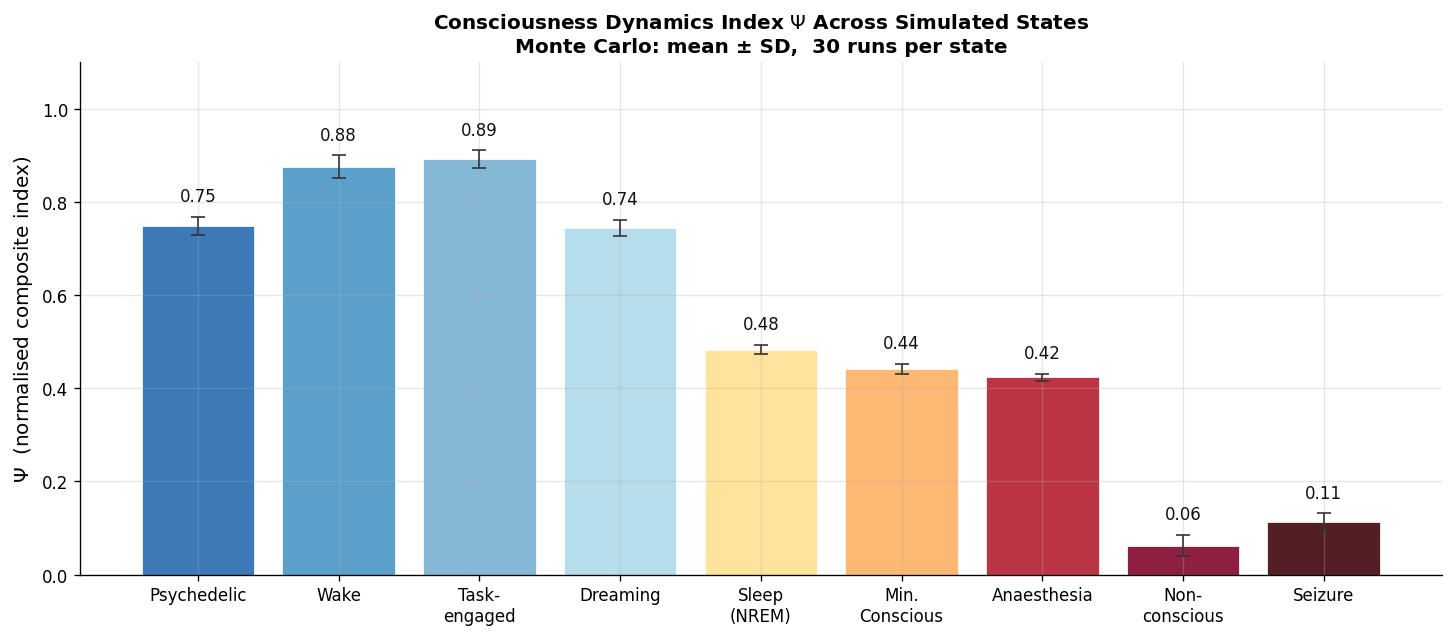

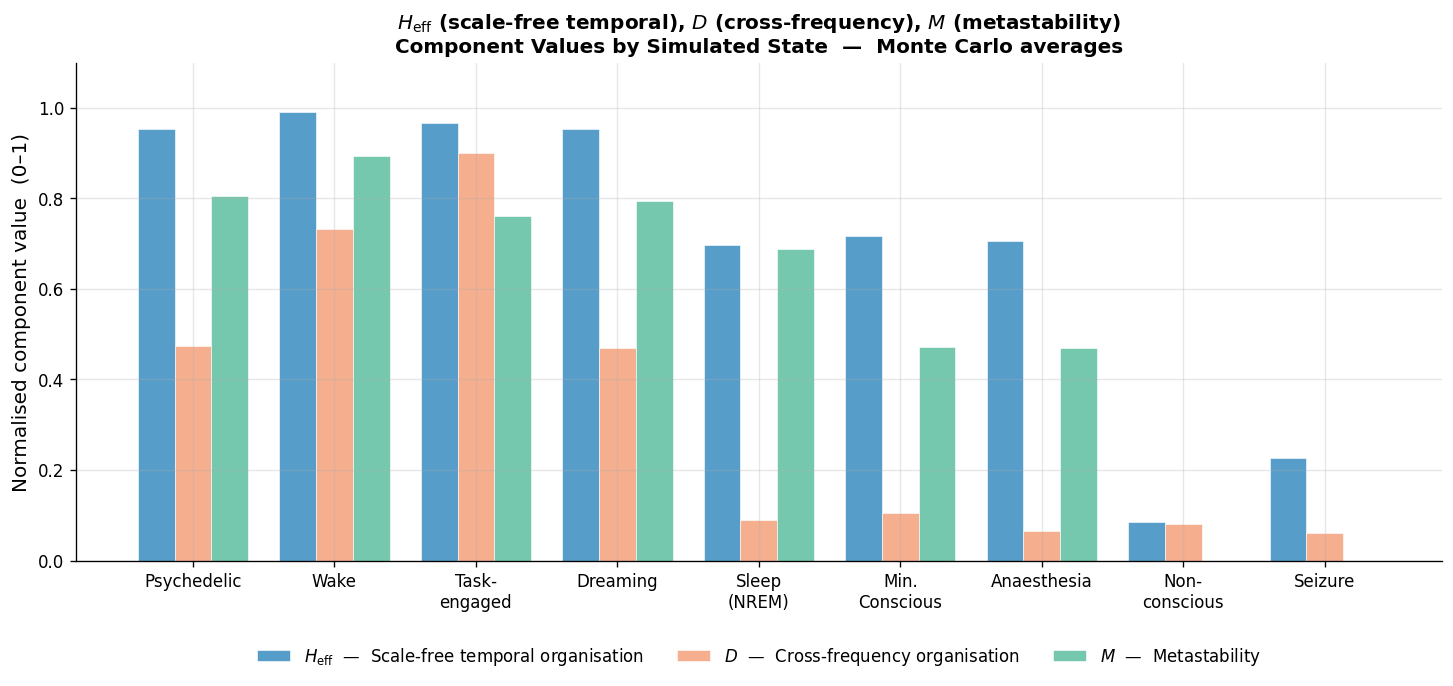

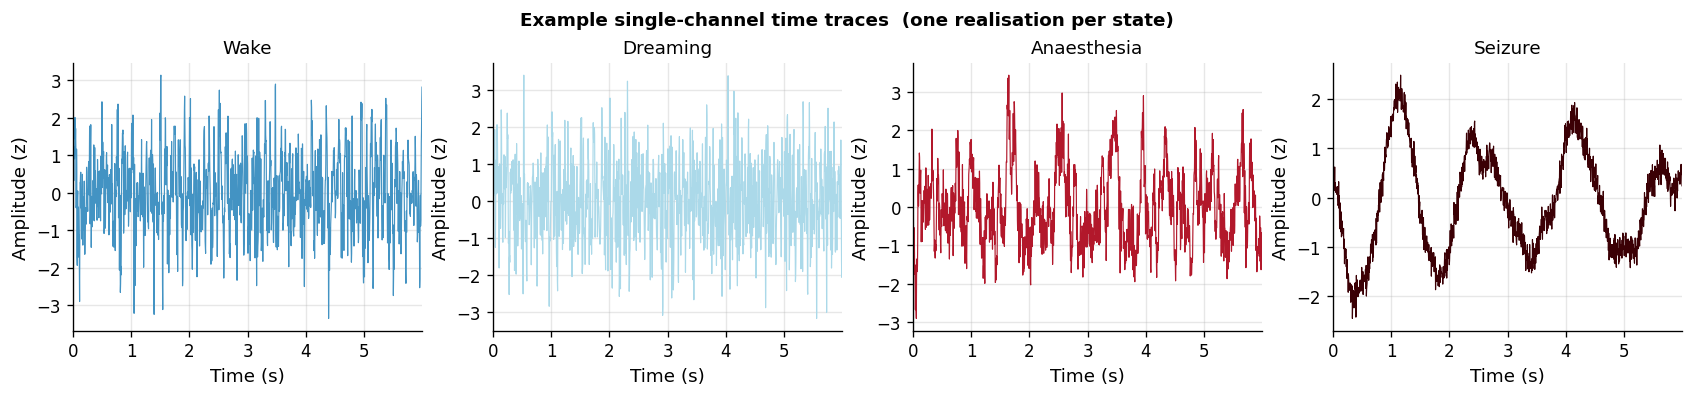

In [10]:
# ── Ooutput figures: Psi bars ± SD and component bars ────────────
#

SHORT = ["Psychedelic", "Wake", "Task-\nengaged", "Dreaming",
         "Sleep\n(NREM)", "Min.\nConscious",
         "Anaesthesia", "Non-\nconscious", "Seizure"]
PALETTE = ["#2166AC", "#4393C3", "#74ADD1", "#ABD9E9",
           "#FEE090", "#FDAE61", "#B2182B", "#800026", "#3B0005"]

means = mc_df.groupby("state")["Psi"].mean().reindex(STATE_ORDER)
sds   = mc_df.groupby("state")["Psi"].std().reindex(STATE_ORDER)

# ══════════════════════════════════════════════════════════════════════════
# Figure 2 — Psi across states, mean ± SD
# ══════════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(12, 5.2), constrained_layout=True)
x = np.arange(len(STATE_ORDER))
ax2.bar(x, means.values, color=PALETTE, alpha=0.88,
        edgecolor="white", linewidth=0.5,
        yerr=sds.values,
        error_kw=dict(elinewidth=1.0, capsize=4, capthick=1.0, ecolor="#333333"))
for xi, (m, sd) in enumerate(zip(means.values, sds.values)):
    ax2.text(xi, m + sd + 0.025, f"{m:.2f}",
             ha="center", va="bottom", fontsize=10, color="#111111")
ax2.set_xticks(x)
ax2.set_xticklabels(SHORT, rotation=0, ha="center", fontsize=10,
                    multialignment="center")
ax2.set_ylabel(r"$\Psi$  (normalised composite index)", fontsize=12)
ax2.set_ylim(0, 1.10)
ax2.set_title(
    r"Consciousness Dynamics Index $\Psi$ Across Simulated States"
    "\n"
    f"Monte Carlo: mean ± SD,  {N_RUNS_PER_STATE} runs per state",
    fontsize=12, fontweight="bold")
plt.show()


# ══════════════════════════════════════════════════════════════════════════
# Figure 5 — Components (H_eff, D, M) by state
# ══════════════════════════════════════════════════════════════════════════
comp_mean = (mc_df.groupby("state")[["H_eff_n", "D_n", "M_n"]]
             .mean().reindex(STATE_ORDER))

fig5, ax5 = plt.subplots(figsize=(12, 5.6), constrained_layout=True)
x5, w5 = np.arange(len(STATE_ORDER)), 0.26
components = [
    ("H_eff_n", r"$H_\mathrm{eff}$  —  Scale-free temporal organisation", "#4393C3"),
    ("D_n",     r"$D$  —  Cross-frequency organisation",                  "#F4A582"),
    ("M_n",     r"$M$  —  Metastability",                                 "#66C2A5"),
]
for i, (col, label, color) in enumerate(components):
    ax5.bar(x5 + (i - 1) * w5, comp_mean[col].values, w5,
            color=color, alpha=0.9, label=label,
            edgecolor="white", linewidth=0.4)
ax5.set_xticks(x5)
ax5.set_xticklabels(SHORT, rotation=0, ha="center", fontsize=10,
                    multialignment="center")
ax5.set_ylabel(r"Normalised component value  (0–1)", fontsize=12)
ax5.set_ylim(0, 1.10)
ax5.set_title(
    r"$H_\mathrm{eff}$ (scale-free temporal), "
    r"$D$ (cross-frequency), $M$ (metastability)"
    "\nComponent Values by Simulated State  —  Monte Carlo averages",
    fontsize=12, fontweight="bold")
ax5.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14),
           ncol=3, fontsize=10, frameon=False)
plt.show()


# ══════════════════════════════════════════════════════════════════════════
# Supplementary — example time traces for 4 representative states
# (same as before, now using the cached first-run realisation per state)
# ══════════════════════════════════════════════════════════════════════════
t_show = np.arange(1500) / CFG["fs"]
fig3, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True)
showcase = [("Wake", "wake"), ("Dreaming", "psychedelic"),
            ("Anaesthesia", "anesthesia"), ("Seizure", "seizure")]
palette_trace = {"Wake":"#4393C3", "Dreaming":"#ABD9E9",
                 "Anaesthesia":"#B2182B", "Seizure":"#3B0005"}
for ax, (disp, key) in zip(axes, showcase):
    if key not in sim_cache:
        ax.set_title(f"{disp}  (no cache)")
        continue
    x_trace = sim_cache[key][0, :1500]
    ax.plot(t_show, x_trace, lw=0.7, color=palette_trace[disp])
    ax.set_title(disp, fontsize=11)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (z)")
    ax.set_xlim(0, t_show[-1])
fig3.suptitle("Example single-channel time traces  (one realisation per state)",
              fontsize=11, fontweight="bold")
plt.show()


## Using these simulators in your own analysis

Every simulator returns a `(n_channels, T)` numpy array, z-scored per channel.
The unified API is:

```python
X = simulate_state_fast(n_channels=16, T=3000, fs=250, state="wake")
```

The `state` argument accepts any of: `wake`, `task_engaged`, `sleep`,
`anesthesia`, `psychedelic`, `dreaming`, `seizure`, `minimally_conscious`,
`non_conscious`, `rem_sleep`.

### Monte Carlo pattern

```python
results = []
for state in ["wake", "psychedelic", "sleep", "anesthesia", "seizure"]:
    for run in range(30):
        X = simulate_state_fast(state=state, n_channels=16, T=3000, fs=250)
        results.append({**compute_all_metrics(X, fs=250), "state": state})

import pandas as pd
mc_df = pd.DataFrame(results)
mc_df["H_eff"] = heff_from_population(mc_df["H"].values, H_opt=0.35)
```



